#Descenso de Gradiente Estocástico y variaciones adaptativas

Usaremos la base de datos **California Housing** de la paquetería Scikit-learn. Esta base de datos trae 8 covariables, y una variable respuesta. Son datos de precios de casas en los distritos del Estado de California. Vamos a plantear una regresión lineal para esta base de datos:

$$Y= \theta_1 X_1 +\theta_2 X_2 + \cdots + \theta_8 X_8.$$

El objetivo es encontrar $\theta^*=(\theta_1^*, ..., \theta_8^*)$ que minimiza la función de pérdida cuadrática. Usaremos varios métodos:



1.   Descenso de Gradiente (GD)
2.   Descenso de Gradiente Estocástico (SGD)
3.   SGD con momentum
4.   AdaGrad
5.   RMSProp
6.   ADAM







## Descenso de gradiente

La regla es $\theta_0 \in \mathbb{R}^d$ y para $n\geq 0:$

$$\theta_{n+1}= \theta_n - \eta_n \nabla \ell (\theta_n).$$

**Observación**: Aquí usamos todos los datos:

In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)
print(housing.feature_names[0:8])

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [ ]:
X = housing.data
y = housing.target

In [ ]:
# beta := lo que en la teoría llamamos theta (el vector de parámetros a ajustar)
def gd_squared_loss(X, Y, learning_rate, num_iterations, beta_initial):
    n_samples = X.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    gradientes = []
    betas = []

    for _ in range(num_iterations):
        gradient = (2 / n_samples) * X.T @ (X @ beta - Y)
        gradientes.append(gradient.copy())
        beta -= learning_rate * gradient
        loss = np.sum((X @ beta - Y) ** 2)/n_samples
        loss_history.append(loss)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
beta_gd, loss_history_gd, betas_gd, gradientes_gd = gd_squared_loss(X_scaled, y, 0.01, 1000, np.zeros(X.shape[1]))

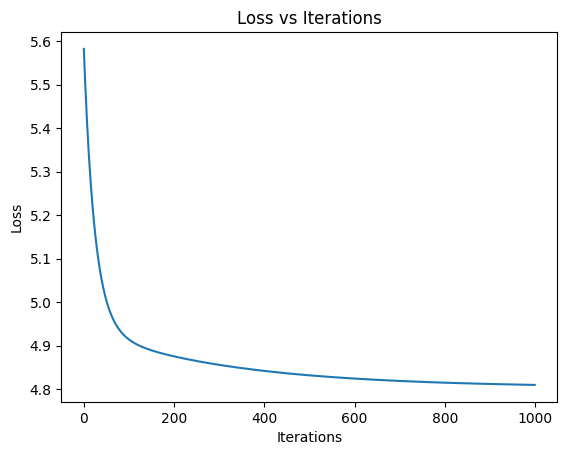

In [ ]:
plt.plot(loss_history_gd)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()

## Descenso de Gradiente Estocástico

In [ ]:
def sgd_squared_loss(X, Y, batch_size, learning_rate, num_iterations, beta_initial):
    n_samples = X.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    gradientes = []
    betas = []

    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        beta -= learning_rate * gradient
        loss = np.sum((X @ beta - Y) ** 2)/n_samples
        loss_history.append(loss)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes

In [ ]:
beta_sgd, loss_history_sgd, betas_sgd, gradientes_sgd = sgd_squared_loss(X_scaled, y, 128, 0.01, 1000, np.zeros(X.shape[1]))

In [ ]:
beta_sgd

array([ 0.82599379,  0.11081716, -0.22427066,  0.21479239,  0.02912087,
       -0.12021798, -0.67063626, -0.66650696])

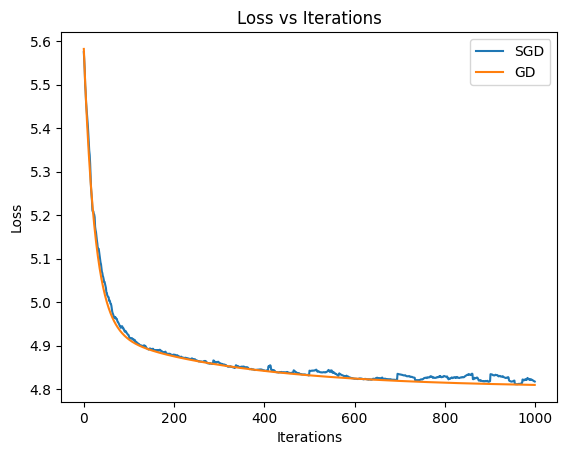

In [ ]:
plt.plot(loss_history_sgd, label= 'SGD')
plt.plot(loss_history_gd, label= 'GD')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()

## SGD con learning rate decay

Mencionamos en algunas lecciones teóricas que una condición sobre las tasas de aprenizaje es que satisfagan lo siguiente:

$$\sum \eta_n = \infty \qquad \text{y} \qquad \sum \eta_n^2<\infty. $$

Ejemplos


*   $\eta_n=\frac{1}{n}$
*   $\eta_n=\frac{1}{n\operatorname{log}n}$



In [ ]:
def sgd_lrd_squared_loss(X, Y, batch_size, num_iterations, beta_initial):
    n_samples = X.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    gradientes = []
    betas = []

    for n in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        beta -= (1/(((n+1)*np.log(n+2)))) * gradient
        loss = np.sum((X @ beta - Y) ** 2)/n_samples
        loss_history.append(loss)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes

In [ ]:
beta_sgd_lrd, loss_history_sgd_lrd, betas_sgd_lrd, gradientes_sgd_lrd = sgd_lrd_squared_loss(X_scaled, y, 128, 1000, np.zeros(X.shape[1]))

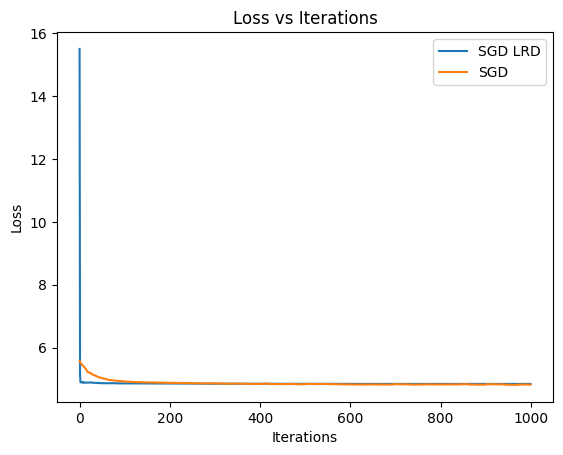

In [ ]:

plt.plot(loss_history_sgd_lrd, label='SGD LRD')
plt.plot(loss_history_sgd, label='SGD')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()

## SGD con momentum

In [ ]:
def sgd_momentum_squared_loss(X, Y, batch_size, learning_rate, alpha, num_iterations, beta_initial):
    n_samples = X.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    gradientes = []
    betas = []
    v = np.zeros_like(beta)
    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        v=alpha*v-learning_rate*(1/(_+1))*gradient
        beta = beta + v
        loss = np.sum((X @ beta - Y) ** 2)/n_samples
        loss_history.append(loss)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes

In [ ]:
beta_sgd_momentum, loss_history_sgd_momentum, betas_sgd_momentum, gradientes_sgd_momentum = sgd_momentum_squared_loss(X_scaled, y, 128, 0.1, 0.9, 1000, np.zeros(X.shape[1]))

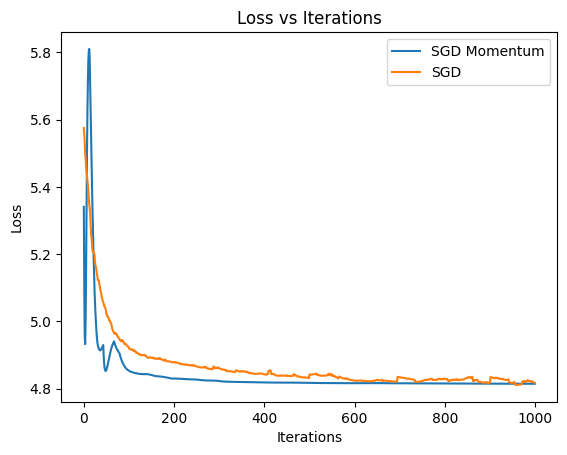

In [ ]:
plt.plot(loss_history_sgd_momentum, label='SGD Momentum')
plt.plot(loss_history_sgd, label='SGD')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()

In [ ]:
vector=np.array( [1,2,3])
vector**2

array([1, 4, 9])

## AdaGrad

In [ ]:
def adagrad_squared_loss(X, Y, batch_size, learning_rate, num_iterations, beta_initial):
    n_samples = X.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    gradientes = []
    betas = []
    r = np.zeros_like(beta)

    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        r=r+gradient**2
        beta = beta - learning_rate * gradient / (np.sqrt(r) + 1e-8)
        loss = np.sum((X @ beta - Y) ** 2)/n_samples
        loss_history.append(loss)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes

In [ ]:
beta_adagrad, loss_history_adagrad, betas_adagrad, gradientes_adagrad = adagrad_squared_loss(X_scaled, y, 128, 0.01, 1000, np.zeros(X.shape[1]))

Text(0.5, 1.0, 'Loss vs Iterations')

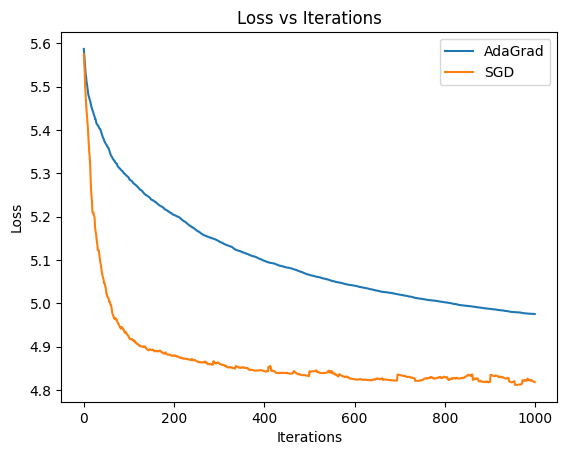

In [ ]:
plt.plot(loss_history_adagrad, label='AdaGrad')
plt.plot(loss_history_sgd, label='SGD')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')

In [ ]:
def adam_squared_loss(X, Y, batch_size, learning_rate, num_iterations, beta_initial, rho_1=0.05, rho_2=0.8):
    n_samples = X.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    gradientes = []
    betas = []
    r = np.zeros_like(beta)
    s = np.zeros_like(beta)

    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        s=rho_1*s+(1-rho_1)*gradient
        r=rho_2*r+(1-rho_2)*gradient**2
        s_tilde=s/(1-rho_1**(_+1))
        r_tilde=r/(1-rho_2**(_+1))
        beta = beta - learning_rate * s_tilde / (np.sqrt(r_tilde) + 1e-8)
        loss = np.sum((X @ beta - Y) ** 2)/n_samples
        loss_history.append(loss)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes

In [ ]:
beta_adam, loss_history_adam, betas_adam, gradientes_adam = adam_squared_loss(X_scaled, y, 256, 0.001, 1000, np.zeros(X.shape[1]))

In [ ]:
beta_adam

array([ 0.84012776,  0.14410936, -0.29332555,  0.3297597 ,  0.01975084,
       -0.24740074, -0.88895439, -0.8503879 ])

In [ ]:
beta_sgd

array([ 0.83090781,  0.13812773, -0.21484637,  0.31244821, -0.011783  ,
       -0.08772525, -0.68649384, -0.64043146])

Text(0.5, 1.0, 'Loss vs Iterations')

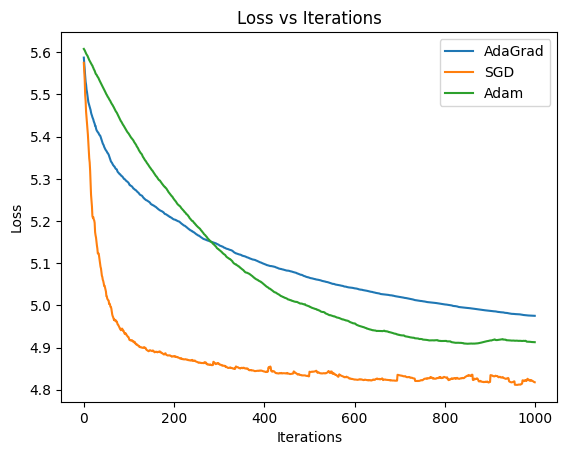

In [ ]:
plt.plot(loss_history_adagrad, label='AdaGrad')
plt.plot(loss_history_sgd, label='SGD')
plt.plot(loss_history_adam, label='Adam')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')

## Tarea

Fecha de entrega: Domingo 2 de agosto
Entregable: Un notebook en Colab, con texto y código
Por cada ejercicio: Un párrafo describiendo el problema, un párrafo de metodología, Resultados (tablas y gráficas) y conclusiones.

1.   Implementar SGD y una de sus variantes (SGD + momentum, AdaGrad, RMSProp, Adam) para la pérdida *cross entropy* y usarlo en un problema de regresión logística con un dataset de imágenes (MNIST, Fashion MNIST, CIFAR 10 , etc)
2.   Estudiar la implementación de SGD en Scikit-learn (ejemplito de uso) (Escoger uno de los dos: SGDRegressor o SGDClassifier)
3.   Estudiar la implementación de SGD en Pytorch (ejemplito de uso)(Escoger dos optimizadores y compararlos)





## Sobreajuste

Queremos observar si alguno de los optimizadores provoca un efecto de **sobreajuste**, es decir, si el modelo aprende demasiado bien los datos de entrenamiento pero pierde capacidad de generalización en datos nuevos.

Para ello, vamos a dividir el dataset en dos partes: un **conjunto de entrenamiento** y un **conjunto de validación**. Luego, entrenaremos el modelo con distintos algoritmos de optimización y **registraremos la pérdida** sobre ambos conjuntos a lo largo de las iteraciones.

Al comparar las curvas de pérdida de entrenamiento y validación, podremos identificar visualmente si ocurre sobreajuste.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
def gd_squared_loss_val(X_train, Y_train, X_val, Y_val, learning_rate, num_iterations, beta_initial):
    n_samples = X_train.shape[0]
    n_val = X_val.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    loss_history_val = []
    gradientes = []
    betas = []

    for _ in range(num_iterations):
        gradient = (2 / n_samples) * X_train.T @ (X_train @ beta - Y_train)
        gradientes.append(gradient.copy())
        beta -= learning_rate * gradient
        loss = np.sum((X_train @ beta - Y_train) ** 2)/n_samples
        loss_history.append(loss)
        loss_val = np.sum((X_val @ beta - Y_val) ** 2)/n_val
        loss_history_val.append(loss_val)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes, loss_history_val

In [ ]:
def sgd_squared_loss_val(X_train, Y_train, X_val, Y_val, batch_size, learning_rate, num_iterations, beta_initial):
    n_samples = X_train.shape[0]
    n_val = X_val.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    loss_history_val = []
    gradientes = []
    betas = []

    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X_train[batch_indices]
        Y_batch = Y_train[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        beta -= learning_rate * gradient
        loss = np.sum((X_train @ beta - Y_train) ** 2)/n_samples
        loss_history.append(loss)
        loss_val = np.sum((X_val @ beta - Y_val) ** 2)/n_val
        loss_history_val.append(loss_val)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes, loss_history_val

In [ ]:
def sgd_lrd_squared_loss_val(X_train, Y_train, X_val, Y_val, batch_size, num_iterations, beta_initial):
    n_samples = X_train.shape[0]
    n_val = X_val.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    loss_history_val = []
    gradientes = []
    betas = []

    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X_train[batch_indices]
        Y_batch = Y_train[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        beta -= (1/(_+1)) * gradient
        loss = np.sum((X_train @ beta - Y_train) ** 2)/n_samples
        loss_history.append(loss)
        loss_val = np.sum((X_val @ beta - Y_val) ** 2)/n_val
        loss_history_val.append(loss_val)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes, loss_history_val

In [ ]:
def sgd_momentum_squared_loss_val(X_train, Y_train, X_val, Y_val, batch_size, learning_rate, alpha, num_iterations, beta_initial):
    n_samples = X_train.shape[0]
    n_val = X_val.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    loss_history_val = []
    gradientes = []
    betas = []
    v = np.zeros_like(beta)
    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X_train[batch_indices]
        Y_batch = Y_train[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        v=alpha*v-learning_rate*gradient
        beta = beta + v
        loss = np.sum((X_train @ beta - Y_train) ** 2)/n_samples
        loss_history.append(loss)
        loss_val = np.sum((X_val @ beta - Y_val) ** 2)/n_val
        loss_history_val.append(loss_val)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes, loss_history_val

In [ ]:
def adagrad_squared_loss_val(X_train, Y_train, X_val, Y_val, batch_size, learning_rate, num_iterations, beta_initial):
    n_samples = X_train.shape[0]
    n_val = X_val.shape[0]
    beta = beta_initial.copy()
    loss_history = []
    loss_history_val = []
    gradientes = []
    betas = []
    r = np.zeros_like(beta)

    for _ in range(num_iterations):
        batch_indices = np.random.choice(range(n_samples), batch_size, replace=False)
        X_batch = X_train[batch_indices]
        Y_batch = Y_train[batch_indices]
        gradient = (2 / batch_size) * X_batch.T @ (X_batch @ beta - Y_batch)
        gradientes.append(gradient.copy())
        r=r+gradient**2
        beta = beta - learning_rate * gradient / (np.sqrt(r) + 1e-8)
        loss = np.sum((X_train @ beta - Y_train) ** 2)/n_samples
        loss_history.append(loss)
        loss_val = np.sum((X_val @ beta - Y_val) ** 2)/n_val
        loss_history_val.append(loss_val)
        betas.append(beta.copy())

    return beta, loss_history, betas, gradientes, loss_history_val

## Evaluación de sobreajuste en GD

In [ ]:
beta_gd_val, loss_history_gd_val, betas_gd_val, gradientes_gd_val, loss_history_val_gd = gd_squared_loss_val(X_train, Y_train, X_val, Y_val, 0.01, 1000, np.zeros(X.shape[1]))


Text(0.5, 1.0, 'Loss vs Iterations')

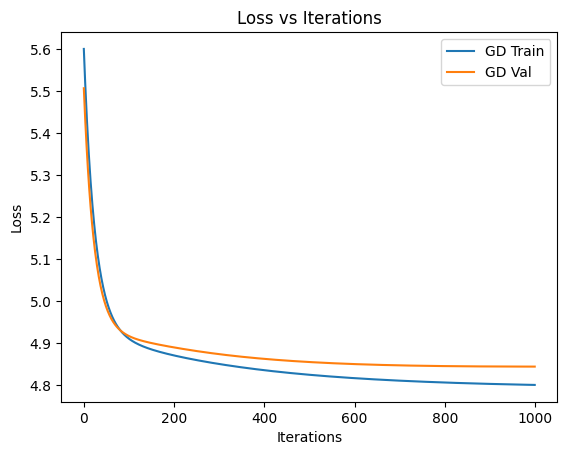

In [ ]:
plt.plot(loss_history_gd_val, label='GD Train')
plt.plot(loss_history_val_gd, label='GD Val')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')

## Evaluación de sobreajuste en SGD

In [ ]:
beta_sgd_val, loss_history_sgd_val, betas_sgd_val, gradientes_sgd, loss_history_val_sgd = sgd_squared_loss_val(X_train, Y_train, X_val, Y_val, 128, 0.001, 2000, np.zeros(X.shape[1]))

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

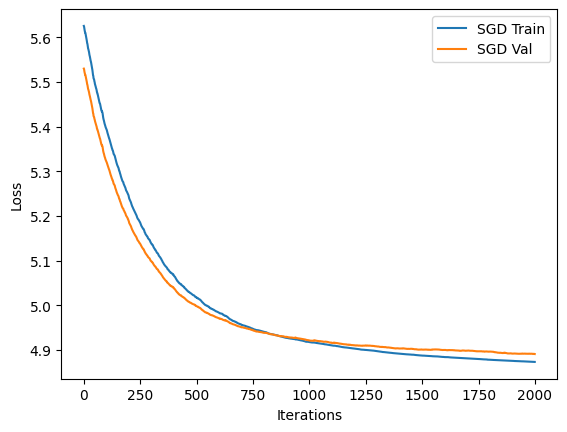

In [ ]:
plt.plot(loss_history_sgd_val, label='SGD Train')
plt.plot(loss_history_val_sgd, label='SGD Val')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt

## Evaluación de sobreajuste en SGD con lrd

In [ ]:
beta_sgd_lrd_val, loss_history_sgd_lrd_val, betas_sgd_lrd_val, gradientes_sgd_lrd, loss_history_val_sgd_lrd = sgd_lrd_squared_loss_val(X_train, Y_train, X_val, Y_val, 256, 1000, np.zeros(X.shape[1]))

Text(0, 0.5, 'Loss')

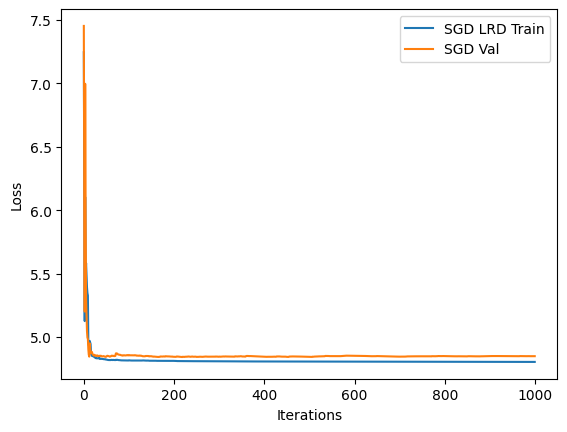

In [ ]:
plt.plot(loss_history_sgd_lrd_val, label='SGD LRD Train')
plt.plot(loss_history_val_sgd_lrd, label='SGD Val')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

## Evaluación de sobreajuste en SGD con momentum

In [ ]:
beta_sgd_momentum_val, loss_history_sgd_momentum_val, betas_sgd_momentum_val, gradientes_sgd_momentum_val, loss_history_val_sgd_momentum = sgd_momentum_squared_loss_val(X_train, Y_train, X_val, Y_val, 256, 0.001, 0.9, 1000, np.zeros(X.shape[1]))

Text(0, 0.5, 'Loss')

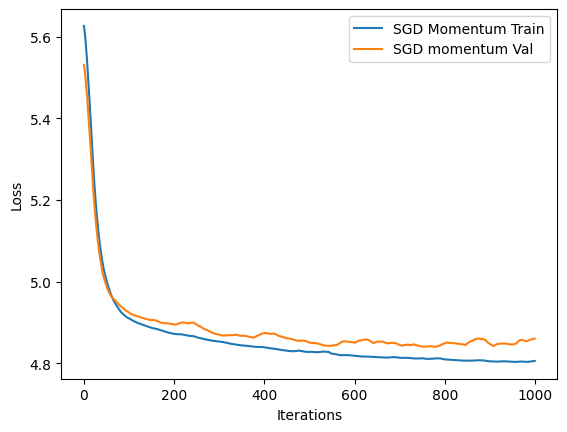

In [ ]:
plt.plot(loss_history_sgd_momentum_val, label='SGD Momentum Train')
plt.plot(loss_history_val_sgd_momentum, label='SGD momentum Val')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

## Evaluación de sobreajuste en AdaGrad

In [ ]:
beta_adagrad_val, loss_history_adagrad_val, betas_adagrad_val, gradientes_adagrad_val, loss_history_val_adagrad = adagrad_squared_loss_val(X_train, Y_train, X_val, Y_val, 64, 0.01, 1000, np.zeros(X.shape[1]))

Text(0, 0.5, 'Loss')

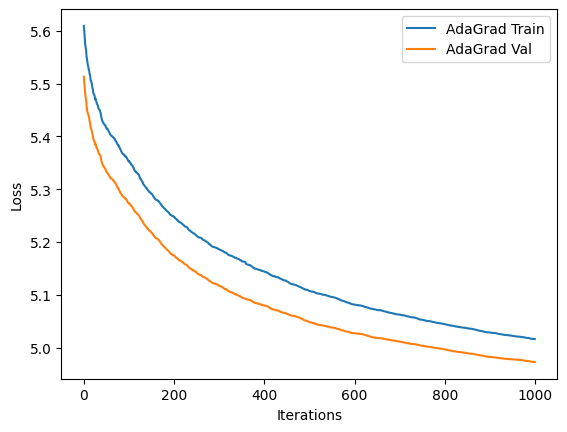

In [ ]:
plt.plot(loss_history_adagrad_val, label='AdaGrad Train')
plt.plot(loss_history_val_adagrad, label='AdaGrad Val')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

# SGD en problemas de clasificación (regresión logística)

## SGD

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# cargar dataset MNIST
mnist = fetch_openml("mnist_784", version=1)
X, y = mnist.data, mnist.target.astype(int)

In [ ]:
one_hot = OneHotEncoder(sparse_output=False)
Y_one_hot = one_hot.fit_transform(y.values.reshape(-1, 1))

In [ ]:
# Convertir a NumPy si aún no lo son
X = X.to_numpy() if not isinstance(X, np.ndarray) else X

In [ ]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Evita problemas numéricos
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
def sgd_cross_entropy(X, Y, batch_size, learning_rate, num_iterations):
    n_samples, n_features = X.shape
    num_classes = Y.shape[1]

    # Inicialización de beta
    beta = np.zeros((n_features, num_classes))

    # Historial de pérdida y norma del gradiente
    loss_history = []
    gradientes_history = []

    for i in range(num_iterations):
        # Seleccionar batch aleatorio
        batch_indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]

        # Predicción con softmax
        logits = X_batch @ beta
        probs = softmax(logits)

        # Calcular y guardar la norma del gradiente
        gradientes = (X_batch.T @ (probs - Y_batch)) / batch_size
        gradientes_history.append(np.linalg.norm(gradientes, 'fro'))

        # Actualizar beta con SGD
        beta -= learning_rate * gradientes

        # Calcular la pérdida de entropía cruzada y guardarla
        cross_entropy = -np.mean(np.sum(Y * np.log(np.clip(softmax(X @ beta), 1e-9, 1)), axis=1))
        loss_history.append(cross_entropy)

    return beta, loss_history, gradientes_history

In [ ]:
beta_class_sgd, loss_history_class_sgd, gradientes_history_class_sgd = sgd_cross_entropy(X, Y_one_hot, 300, 0.01, 500)

KeyboardInterrupt: 

In [ ]:
plt.plot(loss_history_class_sgd, label='SGD')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()

## SGD con decaimiento de la tasa de aprendizaje

In [ ]:
def sgd_cross_entropy_lrd(X, Y, batch_size, num_iterations):
    n_samples, n_features = X.shape
    num_classes = Y.shape[1]

    # Inicialización de beta
    beta = np.zeros((n_features, num_classes))

    # Historial de pérdida y norma del gradiente
    loss_history = []
    gradientes_history = []

    for i in range(num_iterations):
        # Seleccionar batch aleatorio
        batch_indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[batch_indices]
        Y_batch = Y[batch_indices]

        # Predicción con softmax
        logits = X_batch @ beta
        probs = softmax(logits)

        # Calcular y guardar la norma del gradiente
        gradientes = (X_batch.T @ (probs - Y_batch)) / batch_size
        gradientes_history.append(np.linalg.norm(gradientes, 'fro'))

        # Actualizar beta con SGD
        beta -= (1/(i+1)) * gradientes

        # Calcular la pérdida de entropía cruzada y guardarla
        cross_entropy = -np.mean(np.sum(Y_batch * np.log(np.clip(softmax(X_batch @ beta), 1e-9, 1)), axis=1))
        loss_history.append(cross_entropy)

    return beta, loss_history, gradientes_history

In [ ]:
beta_class_sgd_lrd, loss_history_class_sgd_lrd, gradientes_history_class_sgd_lrd = sgd_cross_entropy_lrd(X, Y_one_hot, 300, 500)

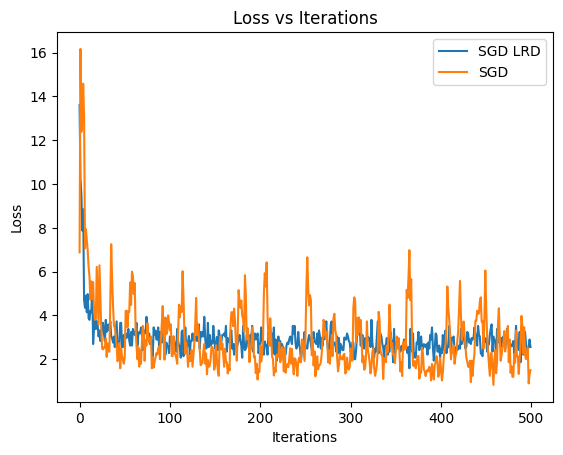

In [ ]:
plt.plot(loss_history_class_sgd_lrd, label='SGD LRD')
plt.plot(loss_history_class_sgd, label='SGD')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()

#Referencias

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Disponible en: [deeplearningbook.org](http://www.deeplearningbook.org)

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning: With Applications in Python*. Springer.